# NSP10-NSP14 Interface Analysis Visualization

**Project**: panCov-rtc-discovery  
**Target**: NSP10-NSP14  
**Author**: Olivier Nsekuye  
**Date**: 2025

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

PROJECT_ROOT = Path.home() / "projects" / "rtc-pan-coronavirus"
VALIDATION_DIR = PROJECT_ROOT / "02-validation" / "NSP10-NSP14"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("✓ Environment ready")

✓ Environment ready


In [2]:
# Load data
with open(VALIDATION_DIR / "validation_result.json") as f:
    validation_data = json.load(f)

with open(VALIDATION_DIR / "interface_analysis.json") as f:
    interface_data = json.load(f)

conservation_nsp10 = pd.read_csv(VALIDATION_DIR / "conservation_NSP10.csv")
conservation_nsp14 = pd.read_csv(VALIDATION_DIR / "conservation_NSP14.csv")

with open(VALIDATION_DIR / "pocket_analysis.json") as f:
    pocket_data = json.load(f)

print(f"✓ Data loaded")
print(f"NSP10 columns: {conservation_nsp10.columns.tolist()}")
print(f"F1 score: {validation_data.get('overall_f1', 'N/A'):.3f}")

✓ Data loaded
NSP10 columns: ['position', 'aa_SARS2', 'conservation', 'entropy', 'is_hotspot', 'all_aas', 'n_sequences']
F1 score: 0.952


## 1. Conservation Heatmap

In [3]:
# Filter to hotspot residues (conservation >= 0.8)
nsp10_hot = conservation_nsp10[conservation_nsp10['conservation'] >= 0.8]
nsp14_hot = conservation_nsp14[conservation_nsp14['conservation'] >= 0.8]

# Create matrices - need to reshape data for heatmap
# The CSV has one row per position, we need to pivot by coronavirus
# First check if we need to load the aligned fasta or use entropy data

print(f"NSP10 hotspots (>=0.8): {len(nsp10_hot)} residues")
print(f"NSP14 hotspots (>=0.8): {len(nsp14_hot)} residues")
print(f"\nTop NSP10 conserved:")
print(nsp10_hot[['position', 'aa_SARS2', 'conservation', 'is_hotspot']].head(10))
print(f"\nTop NSP14 conserved:")
print(nsp14_hot[['position', 'aa_SARS2', 'conservation', 'is_hotspot']].head(10))

NSP10 hotspots (>=0.8): 72 residues
NSP14 hotspots (>=0.8): 285 residues

Top NSP10 conserved:
    position aa_SARS2  conservation  is_hotspot
0          1        A         1.000       False
1          2        G         1.000       False
4          5        T         1.000        True
5          6        E         1.000       False
9         10        N         1.000       False
10        11        S         1.000       False
13        14        L         1.000       False
16        17        C         0.833       False
18        19        F         1.000        True
20        21        V         1.000        True

Top NSP14 conserved:
    position aa_SARS2  conservation  is_hotspot
3          4        V         0.833        True
5          6        G         1.000       False
6          7        L         1.000        True
7          8        F         1.000        True
8          9        K         1.000        True
9         10        D         0.833        True
10        11       

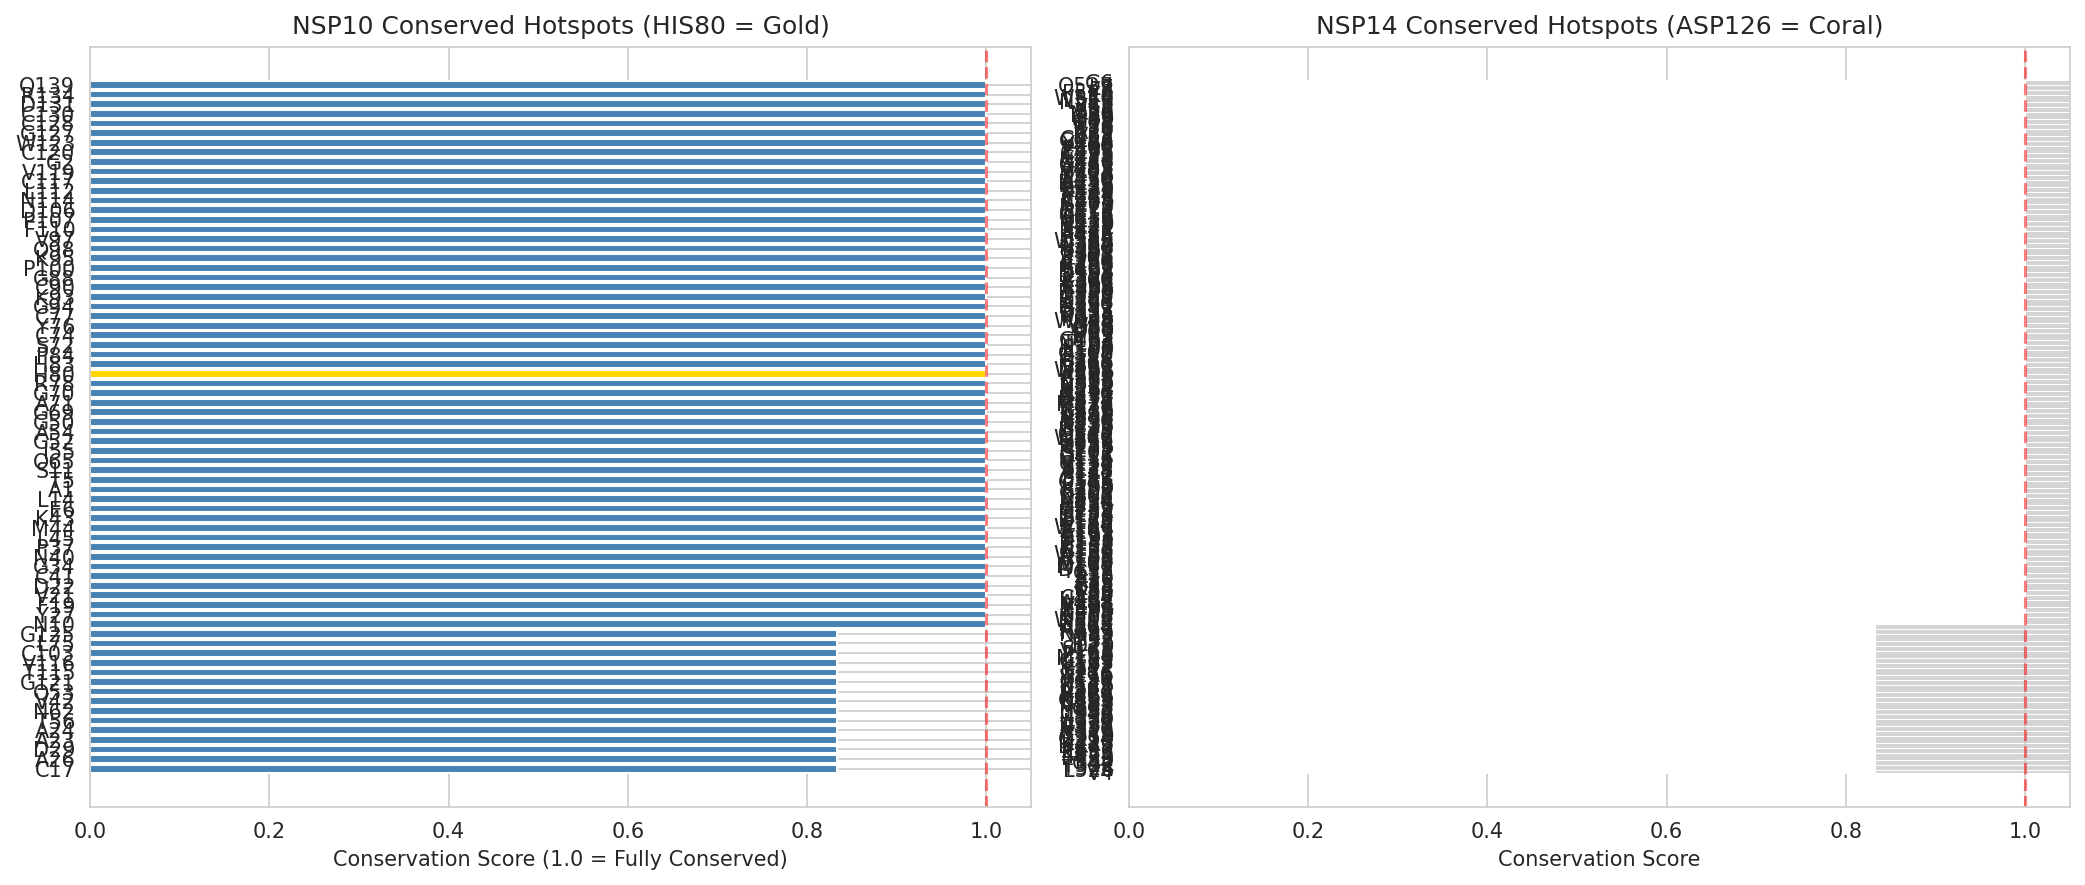


Fully conserved (1.0): NSP10=57, NSP14=224


In [4]:
# Bar chart of conservation scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NSP10 - sort by conservation score
nsp10_plot = nsp10_hot.sort_values('conservation', ascending=True)
colors = ['gold' if pos == 80 else 'steelblue' for pos in nsp10_plot['position']]
axes[0].barh(range(len(nsp10_plot)), nsp10_plot['conservation'], color=colors)
axes[0].set_yticks(range(len(nsp10_plot)))
axes[0].set_yticklabels([f"{aa}{int(pos)}" for aa, pos in zip(nsp10_plot['aa_SARS2'], nsp10_plot['position'])])
axes[0].set_xlabel('Conservation Score (1.0 = Fully Conserved)')
axes[0].set_title('NSP10 Conserved Hotspots (HIS80 = Gold)')
axes[0].axvline(x=1.0, color='red', linestyle='--', alpha=0.5)

# NSP14
nsp14_plot = nsp14_hot.sort_values('conservation', ascending=True)
colors = ['coral' if pos == 126 else 'steelblue' for pos in nsp14_plot['position']]
axes[1].barh(range(len(nsp14_plot)), nsp14_plot['conservation'], color=colors)
axes[1].set_yticks(range(len(nsp14_plot)))
axes[1].set_yticklabels([f"{aa}{int(pos)}" for aa, pos in zip(nsp14_plot['aa_SARS2'], nsp14_plot['position'])])
axes[1].set_xlabel('Conservation Score')
axes[1].set_title('NSP14 Conserved Hotspots (ASP126 = Coral)')
axes[1].axvline(x=1.0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'conservation_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFully conserved (1.0): NSP10={len(nsp10_plot[nsp10_plot['conservation']==1.0])}, NSP14={len(nsp14_plot[nsp14_plot['conservation']==1.0])}")

## 2. 3D Structure (py3Dmol)

In [5]:
import py3Dmol

pdb_path = PROJECT_ROOT / "00-reference" / "pdb_structures" / "7DIY.pdb"
with open(pdb_path) as f:
    pdb_data = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(pdb_data, "pdb")

# Style
view.setStyle({"cartoon": {"color": "lightgray", "opacity": 0.6}})
view.addStyle({"chain": "A"}, {"cartoon": {"color": "lightblue", "opacity": 0.9}})
view.addStyle({"chain": "B"}, {"cartoon": {"color": "lightgreen", "opacity": 0.9}})

# Highlight HIS80 and ASP126
view.addStyle({"chain": "A", "resi": "80"}, {"stick": {"colorscheme": "redCarbon", "radius": 0.4}})
view.addStyle({"chain": "A", "resi": "80"}, {"sphere": {"color": "red", "radius": 0.6}})
view.addStyle({"chain": "B", "resi": "126"}, {"stick": {"colorscheme": "blueCarbon", "radius": 0.4}})
view.addStyle({"chain": "B", "resi": "126"}, {"sphere": {"color": "blue", "radius": 0.6}})

# Labels
view.addLabel("HIS80", {"position": {"chain": "A", "resi": "80", "atom": "CA"}, 
              "backgroundColor": "white", "fontColor": "red", "fontSize": 14})
view.addLabel("ASP126", {"position": {"chain": "B", "resi": "126", "atom": "CA"},
              "backgroundColor": "white", "fontColor": "blue", "fontSize": 14})

view.zoomTo({"chain": ["A", "B"], "resi": ["75-85", "120-130"]})
view.show()

print("Red: HIS80 (NSP10) - Primary drug target")
print("Blue: ASP126 (NSP14) - Salt bridge partner")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Red: HIS80 (NSP10) - Primary drug target
Blue: ASP126 (NSP14) - Salt bridge partner


## 3. Summary Statistics

In [6]:
print("="*60)
print("NSP10-NSP14 SUMMARY")
print("="*60)
print(f"\nValidation F1: {validation_data.get('overall_f1', 0):.3f}")
print(f"AF3 iptm: {validation_data.get('af3_scores', {}).get('iptm', 'N/A')}")
print(f"\nHotspots: NSP10={len(nsp10_hot)}, NSP14={len(nsp14_hot)}")
print(f"Fully conserved: {len(nsp10_hot[nsp10_hot['conservation']==1.0]) + len(nsp14_hot[nsp14_hot['conservation']==1.0])}")

consensus = pocket_data.get('consensus_docking_box', {})
print(f"\nDocking box center: ({consensus.get('center_x')}, {consensus.get('center_y')}, {consensus.get('center_z')})")
print(f"Docking box size: ({consensus.get('size_x'):.1f}, {consensus.get('size_y'):.1f}, {consensus.get('size_z'):.1f}) Å")
print("\n✅ READY FOR VIRTUAL SCREENING")
print("="*60)

NSP10-NSP14 SUMMARY

Validation F1: 0.952
AF3 iptm: N/A

Hotspots: NSP10=72, NSP14=285
Fully conserved: 281

Docking box center: (-3.825, 12.651, -9.697)
Docking box size: (37.8, 31.3, 36.2) Å

✅ READY FOR VIRTUAL SCREENING
